In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier

In [2]:
date = {
    "Alina": [60, 165, True],
    "Bogdan": [72, 183, False],
    "Ciprian": [69, 178, False],
    "Diana": [55, 152, True],
    "Elena": [58, 168, True],
    "Andrei": [80, 185, False],
    "Mihai": [75, 177, False],
    "Irina": [62, 170, True],
    "Florin": [90, 190, False],
    "Maria": [53, 160, True],
    "Vlad": [70, 175, False],
    "Ioana": [50, 155, True],
    "Radu": [68, 172, False],
    "Ana": [59, 162, True],
    "George": [85, 182, False],
    "Larisa": [61, 167, True],
    "Stefan": [78, 180, False],
    "Bianca": [56, 158, True],
    "Paul": [74, 176, False],
    "Oana": [54, 163, True],
    "Cosmin": [82, 188, False],
    "Teodora": [57, 159, True],
    "Ionut": [76, 181, False],
    "Gabriela": [60, 164, True]
}

In [3]:
df = pd.DataFrame(date.values(), columns=["greutate", "inaltime", "voce_subtire"])
df

,greutate,inaltime,voce_subtire
0,60,165,True
1,72,183,False
2,69,178,False
3,55,152,True
4,58,168,True
5,80,185,False
6,75,177,False
7,62,170,True
8,90,190,False
9,53,160,True


In [4]:
df["voce_subtire"] = df["voce_subtire"].map({True:1, False:0})
df

,greutate,inaltime,voce_subtire
0,60,165,1
1,72,183,0
2,69,178,0
3,55,152,1
4,58,168,1
5,80,185,0
6,75,177,0
7,62,170,1
8,90,190,0
9,53,160,1


In [5]:
from sklearn.preprocessing import StandardScaler

In [6]:
scaler = StandardScaler()
scaler

,copy,True
,with_mean,True
,with_std,True


In [7]:
df.head()

,greutate,inaltime,voce_subtire
0,60,165,1
1,72,183,0
2,69,178,0
3,55,152,1
4,58,168,1


In [11]:
scaled_np = scaler.fit_transform(df)
scaled_np

array([[-0.61915453, -0.58660023,  1.        ],
       [ 0.46814123,  1.10280844, -1.        ],
       [ 0.19631729,  0.63352825, -1.        ],
       [-1.07219444, -1.80672872,  1.        ],
       [-0.8003705 , -0.30503212,  1.        ],
       [ 1.19300508,  1.29052052, -1.        ],
       [ 0.73996518,  0.53967222, -1.        ],
       [-0.43793857, -0.11732005,  1.        ],
       [ 2.09908489,  1.7598007 , -1.        ],
       [-1.2534104 , -1.05588042,  1.        ],
       [ 0.28692527,  0.35196014, -1.        ],
       [-1.52523434, -1.52516061,  1.        ],
       [ 0.10570931,  0.07039203, -1.        ],
       [-0.70976252, -0.86816835,  1.        ],
       [ 1.64604498,  1.0089524 , -1.        ],
       [-0.52854655, -0.39888816,  1.        ],
       [ 1.01178912,  0.82124033, -1.        ],
       [-0.98158646, -1.2435925 ,  1.        ],
       [ 0.64935719,  0.44581618, -1.        ],
       [-1.16280242, -0.77431231,  1.        ],
       [ 1.37422104,  1.57208863, -1.   

In [14]:
scaled_df = pd.DataFrame(scaled_np, columns=df.columns)
scaled_df

,greutate,inaltime,voce_subtire
0,-0.619155,-0.586600,1.0
1,0.468141,1.102808,-1.0
2,0.196317,0.633528,-1.0
3,-1.072194,-1.806729,1.0
4,-0.800370,-0.305032,1.0
5,1.193005,1.290521,-1.0
6,0.739965,0.539672,-1.0
7,-0.437939,-0.117320,1.0
8,2.099085,1.759801,-1.0
9,-1.253410,-1.055880,1.0


Text(0, 0.5, 'Inaltime')

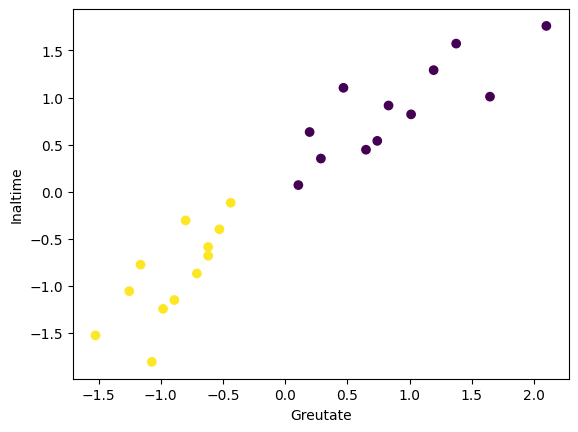

In [15]:
plt.scatter(scaled_df.greutate, scaled_df.inaltime, c=scaled_df.voce_subtire)
plt.xlabel("Greutate")
plt.ylabel("Inaltime")

Text(0, 0.5, 'Inaltime')

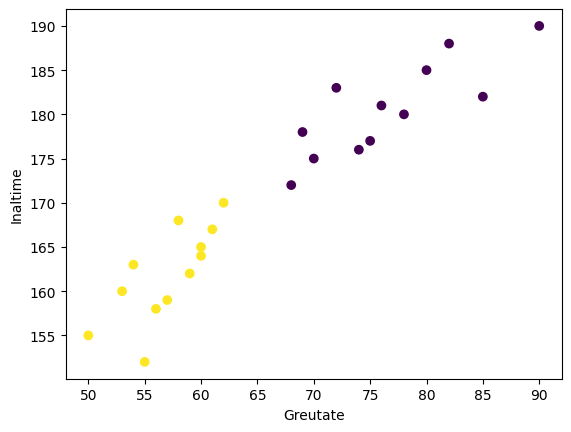

In [16]:
plt.scatter(df.greutate, df.inaltime, c=df.voce_subtire)
plt.xlabel("Greutate")
plt.ylabel("Inaltime")

In [11]:
from sklearn.tree import DecisionTreeClassifier

In [13]:
tree_model = DecisionTreeClassifier()
tree_model.fit(df[["greutate", "inaltime"]], df.voce_subtire)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
import graphviz
from sklearn.tree import export_graphviz

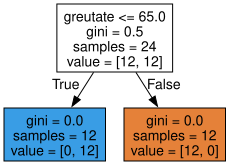

In [18]:
tree_graph = export_graphviz(tree_model, feature_names=["greutate", "inaltime"],filled=True)
graph = graphviz.Source(tree_graph)
graph

Text(0, 0.5, 'Inaltime')

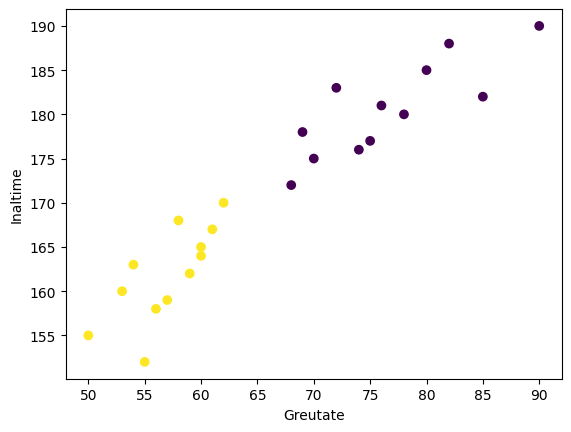

In [19]:
plt.scatter(df.greutate, df.inaltime, c=df.voce_subtire)
plt.xlabel("Greutate")
plt.ylabel("Inaltime")

In [20]:
df.describe()

,greutate,inaltime,voce_subtire
count,24.000000,24.000000,24.000000
mean,66.833333,171.250000,0.500000
std,11.273928,10.883773,0.510754
min,50.000000,152.000000,0.000000
25%,57.750000,162.750000,0.000000
50%,65.000000,171.000000,0.500000
75%,75.250000,180.250000,1.000000
max,90.000000,190.000000,1.000000
